# 🚀 Aplikasi Web Manajemen Keuangan: Klasifikasi Transaksi Otomatis

Notebook ini mengimplementasikan sistem klasifikasi transaksi menggunakan pendekatan **Supervised Learning** untuk mencapai akurasi tinggi (~85%+).

### 🛠️ Teknologi Utama:
| Komponen | Teknologi | Fungsi |
|---|---|---|
| **Embeddings** | Sentence-BERT (E5-Large) | Mengubah teks deskripsi menjadi vektor numerik 1024-dimensi |
| **Classifier** | SVM (RBF Kernel) | Memprediksi kategori transaksi berdasarkan pola vektor |
| **Optimization** | GridSearchCV | Menemukan parameter model terbaik secara otomatis |
| **Prefixing** | `query:` | Meningkatkan akurasi retrieval pada model E5 |

## 📦 Install Dependencies


In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy joblib -q


## ⚙️ Konfigurasi


In [ ]:
DATASET_PATH = "https://drive.google.com/uc?export=download&id=1CUUsfyzZMzBZm7rDRO0VfitSHHbwYbKX"

MODEL_OUTPUT_PATH = "classifier_model.joblib"

# Model embedding
MODEL_NAME = "intfloat/multilingual-e5-large"

CLASSIFIER_TYPE = "svc"

# GridSearch — True untuk mencari parameter C dan Gamma terbaik secara otomatis
USE_GRID_SEARCH = True

print("✓ Konfigurasi siap")
print(f"  Model     : {MODEL_NAME}")
print(f"  Classifier: {CLASSIFIER_TYPE.upper()} (SVM)")
print(f"  GridSearch: {USE_GRID_SEARCH}")


✓ Konfigurasi siap
  Model     : intfloat/multilingual-e5-large
  Classifier: SVC (SVM)
  GridSearch: True


## 📚 Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import time
import joblib
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
)

matplotlib.rcParams['figure.dpi'] = 120

print("✓ Semua library berhasil diimport")


✓ Semua library berhasil diimport


## 1️⃣ Load & Eksplorasi Dataset


Membaca dataset dari:
  https://drive.google.com/uc?export=download&id=1CUUsfyzZMzBZm7rDRO0VfitSHHbwYbKX

Total baris   : 6133
Kolom         : ['Deskripsi', 'Kategori']
kategori: 42
Jumlah kategori: 42
Duplikat      : 0 baris



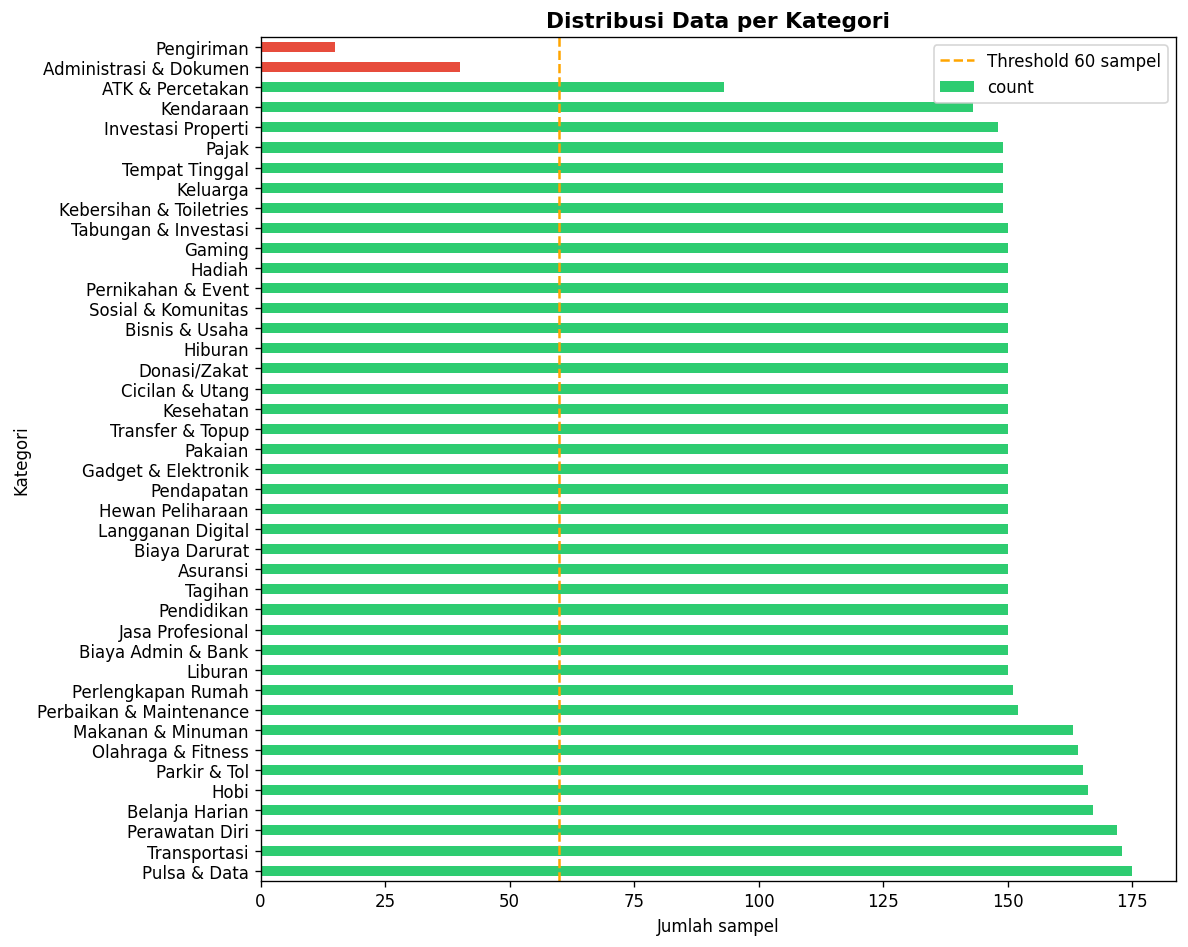


Kategori dengan sampel < 60: 2 kategori
Min sampel: 15 (Pengiriman)
Max sampel: 175 (Pulsa & Data)


In [ ]:
print(f"Membaca dataset dari:\n  {DATASET_PATH}\n")

df = pd.read_csv(DATASET_PATH)

print(f"Total baris   : {len(df)}")
print(f"Kolom         : {df.columns.tolist()}")
print(f"kategori: {df['Kategori'].nunique()}")
print(f"Jumlah kategori: {df['Kategori'].nunique()}")
print(f"Duplikat      : {df.duplicated(subset=['Deskripsi']).sum()} baris")
print()
df.head()

# Distribusi data per kategori
dist = df['Kategori'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v < 60 else '#2ecc71' for v in dist.values]
dist.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=60, color='orange', linestyle='--', linewidth=1.5, label='Threshold 60 sampel')
ax.set_title('Distribusi Data per Kategori', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah sampel')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nKategori dengan sampel < 60: {(dist < 60).sum()} kategori")
print(f"Min sampel: {dist.min()} ({dist.idxmin()})")
print(f"Max sampel: {dist.max()} ({dist.idxmax()})")

In [ ]:
unique_categories = df['Kategori'].unique().tolist()
print(f"Daftar kategori unik:\n{unique_categories}")
print(f"Total kategori unik: {len(unique_categories)}")

Daftar kategori unik:
['Perbaikan & Maintenance', 'Biaya Darurat', 'Tagihan', 'Asuransi', 'Perawatan Diri', 'Kebersihan & Toiletries', 'Jasa Profesional', 'Transportasi', 'Pendidikan', 'Biaya Admin & Bank', 'Parkir & Tol', 'Donasi/Zakat', 'Langganan Digital', 'Keluarga', 'Cicilan & Utang', 'Pajak', 'Belanja Harian', 'Perlengkapan Rumah', 'Gadget & Elektronik', 'ATK & Percetakan', 'Pakaian', 'Tempat Tinggal', 'Pulsa & Data', 'Makanan & Minuman', 'Hewan Peliharaan', 'Pendapatan', 'Olahraga & Fitness', 'Transfer & Topup', 'Kesehatan', 'Hiburan', 'Gaming', 'Hadiah', 'Hobi', 'Tabungan & Investasi', 'Liburan', 'Administrasi & Dokumen', 'Pengiriman', 'Bisnis & Usaha', 'Kendaraan', 'Pernikahan & Event', 'Investasi Properti', 'Sosial & Komunitas']
Total kategori unik: 42


## 2️⃣ Preprocessing


In [ ]:
def clean_text(text: str) -> str:
    """
    Lowercase, buang tanda baca, normalkan spasi.
    Angka pendek (misal '5kg', '50rb') sengaja dibiarkan karena masih relevan untuk klasifikasi.
    Yang dihapus hanya angka 6 digit ke atas seperti nomor rekening atau kode transaksi.
    """
    text = str(text).lower().strip()
    text = re.sub(r'\b\d{6,}\b', '', text)   # no. rekening, kode OTP, dsb
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Hapus missing values
df = df.dropna(subset=['Deskripsi', 'Kategori'])

# Hapus duplikat
n_before = len(df)
df = df.drop_duplicates(subset=['Deskripsi']).reset_index(drop=True)
n_removed = n_before - len(df)
print(f"✓ Duplikat dihapus: {n_removed} baris")
print(f"✓ Dataset bersih  : {len(df)} baris")

# Cleaning teks
df['teks_bersih'] = df['Deskripsi'].apply(clean_text)
print(f"\n✓ Cleaning selesai. Contoh:")
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"  Asli   : {row['Deskripsi']}")
    print(f"  Bersih : {row['teks_bersih']}")
    print()


✓ Duplikat dihapus: 0 baris
✓ Dataset bersih  : 6133 baris

✓ Cleaning selesai. Contoh:
  Asli   : Bayar biaya pindah masuk apartemen
  Bersih : bayar biaya pindah masuk apartemen

  Asli   : Beli baju hamil menyusui
  Bersih : beli baju hamil menyusui

  Asli   : Bayar premi asuransi rawat inap
  Bersih : bayar premi asuransi rawat inap



## 3️⃣ Embedding

Model E5 butuh prefix `"query: "` saat encoding — tanpa ini kualitas embedding turun karena model
tidak tahu konteks penggunaan. Lihat dokumentasi `intfloat/multilingual-e5`.


In [ ]:
def encode_texts(model: SentenceTransformer, texts: list, prefix: str = "query") -> np.ndarray:
    """
    Encode teks ke vektor embedding pakai E5.
    Prefix 'query:' untuk teks yang mau diklasifikasi, 'passage:' untuk dokumen/corpus.
    """
    texts_with_prefix = [f"{prefix}: {t}" for t in texts]
    embeddings = model.encode(
        texts_with_prefix,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,  # normalisasi langsung di encode
    )
    return embeddings


print(f"Memuat model: {MODEL_NAME}")
print("(Unduhan pertama ~beberapa menit)...")

sbert_model = SentenceTransformer(MODEL_NAME)

print(f"\n✓ Model siap!")
print(f"  Dimensi embedding: {sbert_model.get_sentence_embedding_dimension()}")

print("Encoding semua teks ke vektor embedding...")
print(f"prefix: 'query: '\n")

t0 = time.time()
embeddings = encode_texts(sbert_model, df['teks_bersih'].tolist(), prefix="query")
elapsed = time.time() - t0

print(f"\n✓ Embedding selesai dalam {elapsed:.1f}s")
print(f"  Shape : {embeddings.shape}")
print(f"  Dtype : {embeddings.dtype}")
print(f"  Norm sample[0]: {np.linalg.norm(embeddings[0]):.4f} (harus ~1.0)")


Memuat model: intfloat/multilingual-e5-large
(Unduhan pertama ~beberapa menit)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]


✓ Model siap!
  Dimensi embedding: 1024
Encoding semua teks ke vektor embedding...
prefix: 'query: '



/tmp/ipykernel_4574/3420866984.py:22: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"  Dimensi embedding: {sbert_model.get_sentence_embedding_dimension()}")


Batches:   0%|          | 0/192 [00:00<?, ?it/s]


✓ Embedding selesai dalam 901.7s
  Shape : (6133, 1024)
  Dtype : float32
  Norm sample[0]: 1.0000 (harus ~1.0)


## 4️⃣ Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df['Kategori'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['Kategori'],
)

print(f"✓ Data train : {len(X_train)} sampel")
print(f"✓ Data test  : {len(X_test)} sampel")
print(f"✓ Rasio      : {len(X_train)/len(embeddings)*100:.0f}% / {len(X_test)/len(embeddings)*100:.0f}%")


✓ Data train : 4906 sampel
✓ Data test  : 1227 sampel
✓ Rasio      : 80% / 20%


## 5️⃣ Training

SVC kernel RBF dipilih karena embedding yang sudah dinormalisasi ada di hypersphere — SVC lebih
bagus nemuin batas non-linear di sini dibanding LogReg, terutama kalau ada kategori yang mirip-mirip.
GridSearchCV nyari kombinasi C dan gamma terbaik pakai 3-fold cross validation.


In [ ]:
def build_classifier(classifier_type: str, use_grid_search: bool):
    if classifier_type == "svc":
        base_clf = SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42,
        )
        if use_grid_search:
            param_grid = {
                "C"    : [5, 10, 20],
                "gamma": ["scale"],
            }
            return GridSearchCV(
                base_clf, param_grid,
                cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                scoring="f1_macro",
                n_jobs=-1,
                verbose=1,
            )
        else:
            return SVC(kernel="rbf", C=10, gamma="scale",
                       class_weight="balanced", probability=True, random_state=42)

    else:  # logreg
        return LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")


clf = build_classifier(CLASSIFIER_TYPE, USE_GRID_SEARCH)

print(f"Melatih {CLASSIFIER_TYPE.upper()} classifier...")
if USE_GRID_SEARCH:
    print("GridSearchCV aktif — ini butuh beberapa menit, harap tunggu...\n")

# verbose=1 di GridSearchCV sudah cukup buat liat progres per-fold
t0 = time.time()
clf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\n✓ Training selesai dalam {elapsed:.1f}s")

if USE_GRID_SEARCH and hasattr(clf, 'best_params_'):
    print(f"\n  Parameter terbaik  : {clf.best_params_}")
    print(f"  CV F1-macro terbaik: {clf.best_score_:.4f} ({clf.best_score_*100:.2f}%)")


Melatih SVC classifier...
GridSearchCV aktif — ini butuh beberapa menit, harap tunggu...

Fitting 3 folds for each of 3 candidates, totalling 9 fits

✓ Training selesai dalam 270.6s

  Parameter terbaik  : {'C': 5, 'gamma': 'scale'}
  CV F1-macro terbaik: 0.8296 (82.96%)


## 6️⃣ Evaluasi Model


  AKURASI TOTAL: 87.20%

                         precision    recall  f1-score   support

       ATK & Percetakan       0.65      0.94      0.77        18
 Administrasi & Dokumen       0.67      0.75      0.71         8
               Asuransi       0.94      1.00      0.97        30
         Belanja Harian       0.77      0.91      0.83        33
     Biaya Admin & Bank       0.93      0.90      0.92        30
          Biaya Darurat       0.90      0.87      0.88        30
         Bisnis & Usaha       0.88      0.77      0.82        30
        Cicilan & Utang       0.84      0.87      0.85        30
           Donasi/Zakat       1.00      0.97      0.98        30
    Gadget & Elektronik       0.94      0.97      0.95        30
                 Gaming       1.00      1.00      1.00        30
                 Hadiah       0.91      1.00      0.95        30
       Hewan Peliharaan       0.90      0.90      0.90        30
                Hiburan       0.94      0.97      0.95        30

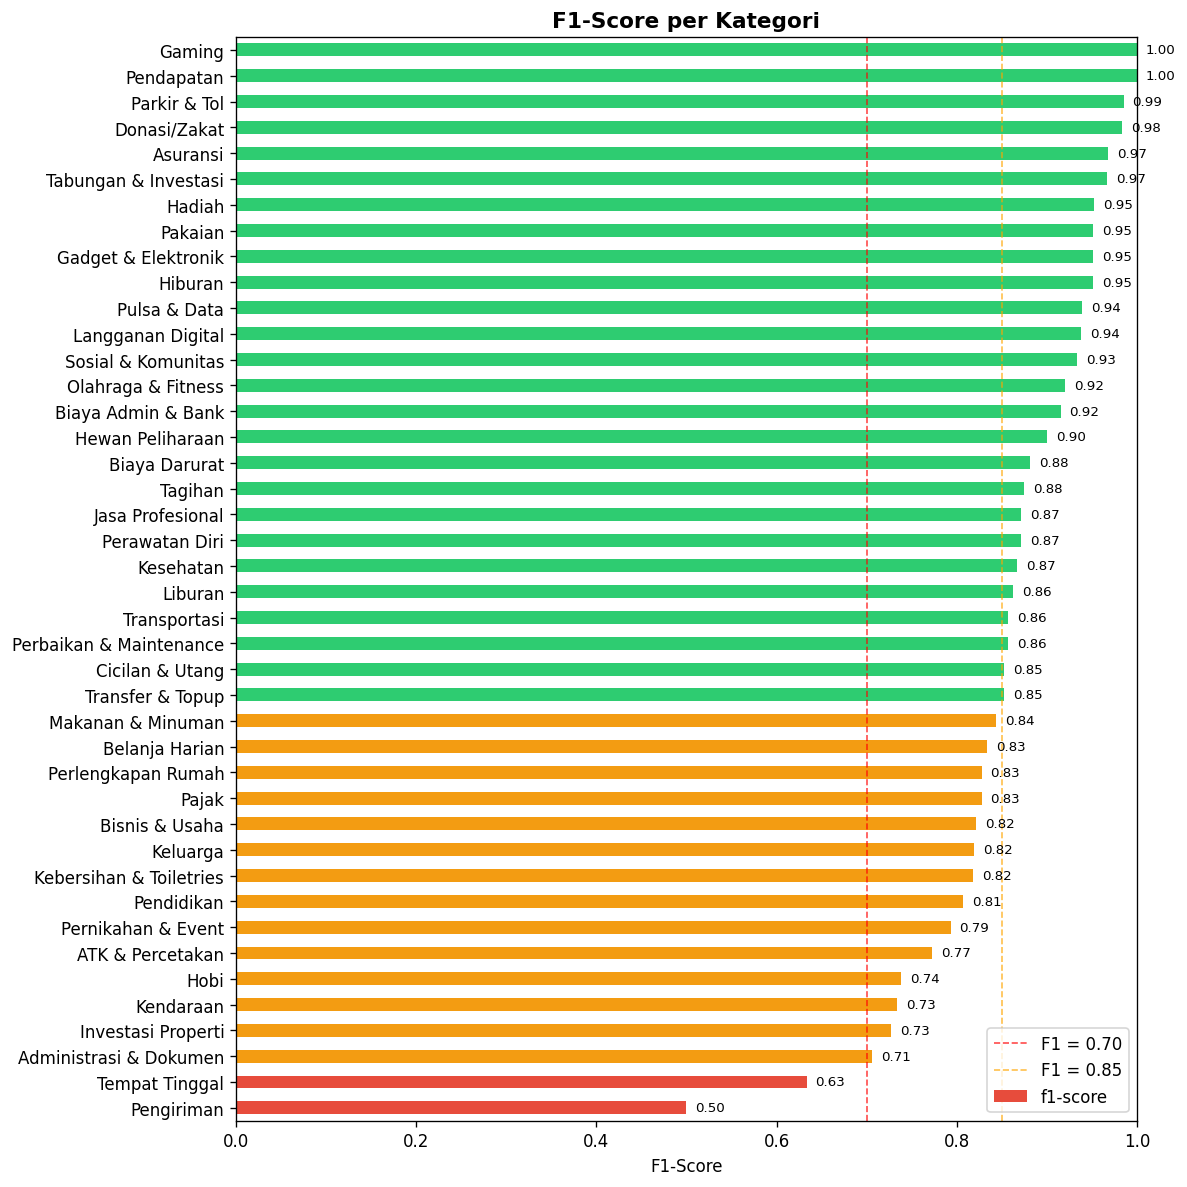

Kategori dengan F1 < 0.75 (6 kategori):
  Pengiriman                     F1=0.50
  Tempat Tinggal                 F1=0.63
  Administrasi & Dokumen         F1=0.71
  Investasi Properti             F1=0.73
  Kendaraan                      F1=0.73
  Hobi                           F1=0.74


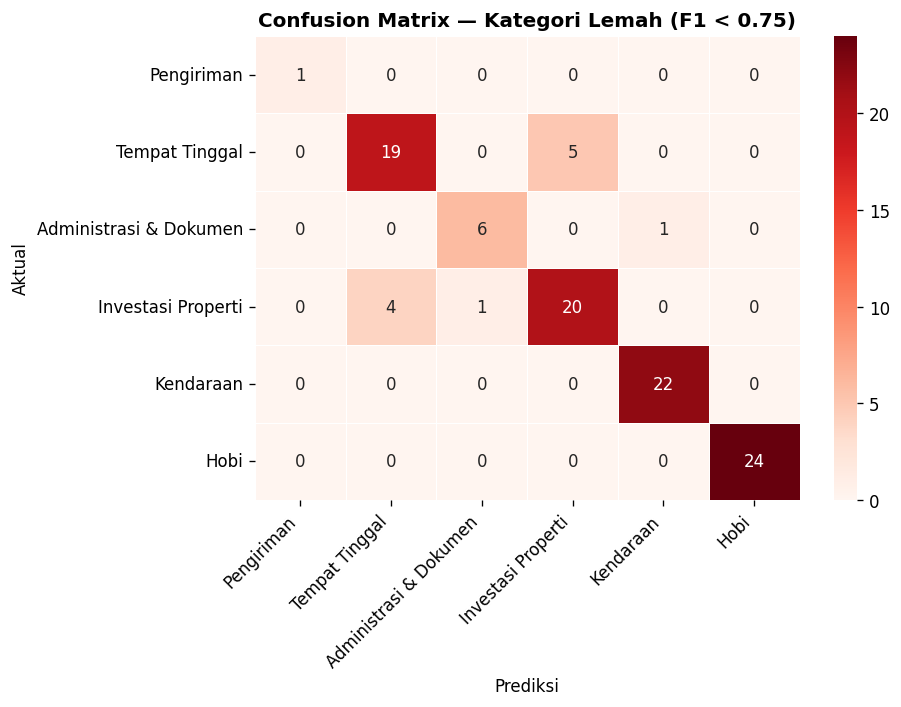

In [ ]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"  AKURASI TOTAL: {acc * 100:.2f}%")
print("=" * 60)
print()
print(classification_report(y_test, y_pred))

# Visualisasi F1-score per kategori
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).T
df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'])
df_report = df_report.sort_values('f1-score')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v < 0.7 else '#f39c12' if v < 0.85 else '#2ecc71'
          for v in df_report['f1-score']]
df_report['f1-score'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0.7,  color='red',    linestyle='--', linewidth=1, alpha=0.7, label='F1 = 0.70')
ax.axvline(x=0.85, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='F1 = 0.85')
ax.set_xlim(0, 1)
ax.set_title('F1-Score per Kategori', fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score')
ax.legend(loc='lower right')

# Label nilai di kanan bar
for i, v in enumerate(df_report['f1-score']):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Confusion matrix untuk kategori dengan F1 < 0.75
# Identifikasi kategori lemah
weak_cats = df_report[df_report['f1-score'] < 0.75].index.tolist()
print(f"Kategori dengan F1 < 0.75 ({len(weak_cats)} kategori):")
for cat in weak_cats:
    f1 = df_report.loc[cat, 'f1-score']
    print(f"  {cat:<30} F1={f1:.2f}")

if weak_cats:
    mask_test = [y in weak_cats for y in y_test]
    y_test_weak = [y_test[i] for i in range(len(y_test)) if mask_test[i]]
    y_pred_weak = [y_pred[i] for i in range(len(y_pred)) if mask_test[i]]

    cm = confusion_matrix(y_test_weak, y_pred_weak, labels=weak_cats)

    fig, ax = plt.subplots(figsize=(max(8, len(weak_cats)*0.8), max(6, len(weak_cats)*0.7)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=weak_cats, yticklabels=weak_cats, ax=ax,
                linewidths=0.5)
    ax.set_title('Confusion Matrix — Kategori Lemah (F1 < 0.75)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 7️⃣ Simpan Model


In [ ]:
# Simpan classifier beserta metadata penting
model_bundle = {
    "classifier"      : clf,
    "model_name"      : MODEL_NAME,
    "classifier_type" : CLASSIFIER_TYPE,
    "accuracy"        : acc,
    "prefix"          : "query",  # PENTING: simpan prefix untuk inferensi
    "kategori_list"   : sorted(df['Kategori'].unique().tolist()),
}

joblib.dump(model_bundle, MODEL_OUTPUT_PATH)
print(f"✓ Model disimpan ke: {MODEL_OUTPUT_PATH}")
print(f"  Akurasi  : {acc * 100:.2f}%")
print(f"  Kategori : {len(model_bundle['kategori_list'])} kategori")


✓ Model disimpan ke: classifier_model.joblib
  Akurasi  : 87.20%
  Kategori : 42 kategori


### 📥 Download Model ke Lokal
Jika Anda mendapatkan error 'Failed to fetch', jalankan cell di bawah ini untuk mendownload file model ke komputer Anda.

In [ ]:
from google.colab import files
import os

if os.path.exists(MODEL_OUTPUT_PATH):
    files.download(MODEL_OUTPUT_PATH)
else:
    print(f"File {MODEL_OUTPUT_PATH} tidak ditemukan. Pastikan Anda sudah menjalankan proses training.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8️⃣ Inferensi — Cara Pakai Model

Gunakan fungsi di bawah ini di FastAPI atau script lain. **Pastikan selalu menggunakan prefix `query: `** yang sama seperti saat training.


In [ ]:
# load sekali di sini, bukan di dalam fungsi predict
# kalau di-load tiap request, tiap panggilan bakal baca file ~1GB dari disk
_bundle      = joblib.load(MODEL_OUTPUT_PATH)
_clf         = _bundle["classifier"]
_prefix      = _bundle.get("prefix", "query")
_sbert       = SentenceTransformer(_bundle["model_name"])

# kalau pakai GridSearchCV, .classes_ ada di best_estimator_-nya
_classes = (_clf.classes_ if hasattr(_clf, 'classes_')
            else _clf.best_estimator_.classes_)

print(f"✓ Model inference siap ({len(_classes)} kategori)")


def predict_kategori(text: str, top_k: int = 3):
    """
    Prediksi kategori untuk satu deskripsi transaksi.
    Return: (prediksi_utama, [(kategori, confidence%), ...])
    """
    clean   = clean_text(text)
    emb     = _sbert.encode([f"{_prefix}: {clean}"], normalize_embeddings=True)
    pred    = _clf.predict(emb)[0]
    proba   = _clf.predict_proba(emb)[0]

    top_idx    = np.argsort(proba)[-top_k:][::-1]
    top_results = [(_classes[i], round(float(proba[i]) * 100, 1)) for i in top_idx]

    return pred, top_results


print("✓ Fungsi predict_kategori siap digunakan")

# ── Uji prediksi ─────────────────────────────────────────────
test_cases = [
    "beli kopi janji jiwa dan roti",
    "bayar makan pakai gopay",
    "transfer ke mama lewat BCA mobile",
    "bayar gym membership bulanan",
    "beli cat akrilik untuk melukis",
    "bayar tagihan listrik PLN",
    "topup OVO untuk belanja",
    "beli beras 5kg di pasar",
]

print(f"{'Teks':<40} {'Prediksi':<25} {'Confidence':<10}")
print("-" * 80)

for teks in test_cases:
    pred, top3 = predict_kategori(teks)
    conf = top3[0][1]
    print(f"{teks[:38]:<40} {pred:<25} {conf:>6.1f}%")

print()
print("Detail top-3 untuk kasus pertama:")
pred, top3 = predict_kategori(test_cases[0])
for kat, score in top3:
    bar = '█' * int(score / 5)
    print(f"  {kat:<25} {score:>5.1f}% {bar}")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model inference siap (42 kategori)
✓ Fungsi predict_kategori siap digunakan
Teks                                     Prediksi                  Confidence
--------------------------------------------------------------------------------
beli kopi janji jiwa dan roti            Makanan & Minuman           84.7%
bayar makan pakai gopay                  Makanan & Minuman           74.2%
transfer ke mama lewat BCA mobile        Transfer & Topup            76.9%
bayar gym membership bulanan             Olahraga & Fitness          97.0%
beli cat akrilik untuk melukis           Hobi                        99.1%
bayar tagihan listrik PLN                Tagihan                     99.3%
topup OVO untuk belanja                  Transfer & Topup            92.6%
beli beras 5kg di pasar                  Belanja Harian              91.3%

Detail top-3 untuk kasus pertama:
  Makanan & Minuman          84.7% ████████████████
  Belanja Harian             10.0% ██
  Bisnis & Usaha              1.1% 


### 🧪 Uji Model dengan Contoh Baru


In [ ]:
# ── Uji prediksi dengan input user ─────────────────────────────

print("Masukkan deskripsi transaksi (ketik 'exit' untuk keluar):\n")

while True:
    user_input = input("Deskripsi: ")
    if user_input.lower() == 'exit':
        break

    if user_input:
        pred, top3 = predict_kategori(user_input)
        print(f"  Prediksi Utama  : {pred}")
        print(f"  Top-K Prediksi  :")
        for kat, score in top3:
            bar = '█' * int(score / 5)
            print(f"    - {kat:<25} {score:>5.1f}% {bar}")
    else:
        print("  Deskripsi tidak boleh kosong.")
    print("\n" + "-" * 50 + "\n")


Masukkan deskripsi transaksi (ketik 'exit' untuk keluar):

  Prediksi Utama  : Tagihan
  Top-K Prediksi  :
    - Tagihan                    41.8% ████████
    - Transfer & Topup           14.3% ██
    - Kendaraan                   6.8% █

--------------------------------------------------



In [ ]:
"""### 🧪 Input Deskripsi Massal"""

# Tulis deskripsi satu per baris
deskripsi_list = """
Bayar premi jiwa tahunan BCA Life
Belanja sayur dan bumbu dapur di Indomaret
Biaya transfer antar bank BRI ke Mandiri
Bayar tambal ban motor mendadak pinggir jalan
Cetak banner promosi untuk toko online
Bayar angsuran motor bulan ini
Transfer zakat penghasilan ke BAZNAS
Beli headphone Sony WH-1000XM5
Beli skin karakter di Mobile Legends
Beli bunga dan coklat ulang tahun sahabat
Beli makanan kering kucing Royal Canin
Nonton konser Coldplay di GBK
Beli cat watercolor Winsor & Newton
Bayar uang muka apartemen di Serpong
Bayar jasa desain logo brand baru
Beli sabun muka Cetaphil dan toner
Kirim uang bulanan ke adik di Bandung
Ganti oli mesin Yamaha NMAX
Beli obat batuk dan vitamin C di apotek
Bayar biaya fotokopi dan jilid dokumen
Bayar Netflix dan Spotify bulan ini
Pesan tiket pesawat Bali pp
Makan siang di warteg depan kantor
Bayar iuran gym bulan Januari
Bayar pajak penghasilan tahunan SPT
Beli kemeja flanel untuk kerja
Bayar parkir mall tiga jam
Terima gaji bulan Maret
Bayar SPP kursus bahasa Inggris
Potong rambut dan creambath di salon
Pasang keramik kamar mandi bocor
Beli rak buku kayu untuk ruang tamu
DP catering pernikahan adik
Isi paket data Telkomsel 30 hari
Bayar iuran RT dan kebersihan lingkungan
Transfer ke rekening deposito BCA
Bayar tagihan air PDAM bulan ini
Bayar kos bulanan daerah Tebet
Topup saldo GoPay untuk belanja
Naik Grab dari rumah ke stasiun
""".strip().splitlines()

print(f"Total input: {len(deskripsi_list)} deskripsi\n")
print(f"{'No':<4} {'Deskripsi':<45} {'Prediksi':<25} {'Confidence'}")
print("-" * 95)

for i, teks in enumerate(deskripsi_list, 1):
    teks = teks.strip()
    if not teks:
        continue
    pred, top3 = predict_kategori(teks)
    conf = top3[0][1]
    print(f"{i:<4} {teks[:43]:<45} {pred:<25} {conf:>6.1f}%")

## 💡 Tips Meningkatkan Akurasi Lebih Lanjut

Jika akurasi masih ingin ditingkatkan di atas 90%:

| Langkah | Estimasi Effort | Estimasi Gain |
|---------|----------------|---------------|
| Tambah data per kategori lemah (target 150+ sampel unik) | Sedang | +3–5% |
| Fine-tune IndoBERT (`indobenchmark/indobert-base-p2`) | Tinggi | +5–10% |
| Ensemble SVC + LogReg dengan voting | Rendah | +1–2% |
| Augmentasi parafrase dengan LLM | Sedang | +2–4% |

Kategori yang masih perlu perhatian ekstra:
- **Hobi** vs **Olahraga & Fitness** — perlu lebih banyak contoh yang jelas berbeda
- **Belanja Harian** vs **Makanan & Minuman** — perlu panduan anotasi yang lebih ketat
- **Lainnya** — definisi terlalu luas, pertimbangkan untuk dipecah atau diperketat

## 🏁 Kesimpulan

Notebook ini telah berhasil mengimplementasikan sistem klasifikasi transaksi otomatis dengan alur:
1. **Text Preprocessing**: Pembersihan deskripsi transaksi.
2. **Feature Extraction**: Menggunakan Sentence-BERT (E5-Large) untuk embedding berkualitas tinggi.
3. **Classification**: Menggunakan SVM dengan RBF Kernel yang dioptimasi melalui GridSearchCV.

Model ini siap diekspor dan digunakan dalam aplikasi web manajemen keuangan Anda.
